# 02 — Tokenização BPE byte-level

> Escopo: BPE byte-level — treino dos merges, encoding e escolha de `vocab_size`.
> O modelo não vê texto: vê **inteiros**. O tokenizer é a ponte texto ↔ IDs, e a
> primeira decisão de arquitetura de dados do projeto.

Antes de qualquer embedding, é preciso decidir *o que é um token*. Este notebook
implementa, do zero e rodável, o **Byte Pair Encoding (BPE) byte-level** — o mesmo
desenho do GPT-2. Ao final você terá um tokenizer que treina merges, codifica e
decodifica com round-trip perfeito, e vai entender cada trade-off por trás dele.

Este notebook alimenta o stub **`src/tucanoce/tokenizer/bpe.py`**: o que você
construir aqui é o que preenche aquele arquivo.

**O que você vai sair sabendo:**
1. Por que char-level escala mal e por que BPE resolve os dois problemas dele.
2. Por que "byte-level" (0–255) e não "caractere Unicode".
3. O algoritmo de treino de merges (Algorithm 1) — implementado de verdade.
4. Encoding/decoding (Algorithm 2) com round-trip garantido.
5. Como escolher `vocab_size` olhando o custo da embedding table `V×d`.
6. O ciclo de vida do cache de tokens e a armadilha do `mtime`.

In [1]:
import re
from collections import Counter
import matplotlib.pyplot as plt

# Convenção visual do projeto (mesma do nb 00).
plt.rcParams.update({
    "figure.figsize": (6, 4), "figure.dpi": 100,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

# Corpus de brinquedo: frases de física em inglês (mesmo domínio do projeto).
# Pequeno de propósito — o algoritmo é o mesmo em 60 MB, só mais lento.
CORPUS = [
    "the electron is a fundamental particle with negative charge",
    "quantum mechanics describes the behavior of particles at small scales",
    "the energy of a photon is proportional to its frequency",
    "in quantum field theory particles are excitations of fields",
    "the mass of the electron is much smaller than the mass of the proton",
    "energy and mass are related by the famous equation e equals m c squared",
    "the electromagnetic field carries energy and momentum through space",
    "particles with half integer spin are called fermions",
    "the quantum state of a particle is described by its wavefunction",
    "conservation of energy is a fundamental principle of physics",
] * 6   # repetição p/ dar frequência aos pares e merges significativos
print(f"{len(CORPUS)} documentos, {sum(len(d) for d in CORPUS)} caracteres")

60 documentos, 3744 caracteres


## 1. Por que não char-level (nb 02)

A primeira versão do projeto usava **tokenização por caractere**: cada caractere
Unicode vira um token. É simples e sem ambiguidade, mas tem dois problemas.

**Problema 1 — vocabulário com cauda longa de raros.** Numa Wikipedia real, a
tabela de caracteres únicos passa de 600 entradas, e centenas aparecem menos de
10 vezes (símbolos, alfabetos estrangeiros). Tokens raros são mal treinados.

**Problema 2 — contexto curto.** Com `context_len` fixo, o modelo vê poucos
*caracteres*. Uma palavra como "mathematics" já consome 11 tokens. O modelo gasta
capacidade aprendendo a juntar letras antes de aprender semântica.

Vamos medir os dois no nosso corpus.

In [2]:
text = " ".join(CORPUS)

# Problema 1: quantos caracteres únicos, e quantos são raros?
char_counts = Counter(text)
raros = [c for c, n in char_counts.items() if n < 10]
print(f"caracteres únicos: {len(char_counts)}")
print(f"aparecem < 10x   : {len(raros)}  -> {sorted(raros)[:15]}")

# Problema 2: 'mathematics' consome 1 token por caractere no char-level
palavra = "mathematics"
print(f"\nchar-level: '{palavra}' = {len(palavra)} tokens "
      f"(um por caractere) -> {list(palavra)}")
print("Objetivo do BPE: '"+palavra+"' virar 1-3 tokens, não 11.")

caracteres únicos: 24
aparecem < 10x   : 1  -> ['x']

char-level: 'mathematics' = 11 tokens (um por caractere) -> ['m', 'a', 't', 'h', 'e', 'm', 'a', 't', 'i', 'c', 's']
Objetivo do BPE: 'mathematics' virar 1-3 tokens, não 11.


## 2. Por que byte-level (nb 02)

BPE byte-level, como no GPT-2, opera sobre **bytes (0–255)**, não sobre caracteres
Unicode. Isso tem uma vantagem decisiva: **qualquer texto** — qualquer idioma,
emoji, símbolo matemático — é representável, porque todo texto é uma sequência de
bytes em UTF-8. Não existe `<UNK>`; nada fica de fora.

O vocabulário inicial são os **256 bytes possíveis** mais alguns tokens especiais
(no nosso caso, só `<|endoftext|>`). Os merges vão *crescer* o vocabulário a partir
daí, fundindo pares frequentes de bytes em subpalavras.

Veja como um caractere fora do ASCII vira **vários bytes** em UTF-8:

In [3]:
for s in ["a", "é", "π", "⚛", "😀"]:
    b = s.encode("utf-8")
    print(f"{s!r:6} -> {len(b)} byte(s): {list(b)}")

# 'a' cabe em 1 byte (ASCII); acentos/símbolos/emoji ocupam 2-4 bytes.
# É por isso que o vocab inicial precisa exatamente dos 256 valores de byte:
# cobre qualquer entrada possível sem buracos.
assert "é".encode("utf-8") == bytes([0xC3, 0xA9])
print("\nvocab inicial = 256 bytes + especiais. Sem <UNK>, cobertura total.")

'a'    -> 1 byte(s): [97]
'é'    -> 2 byte(s): [195, 169]
'π'    -> 2 byte(s): [207, 128]
'⚛'    -> 3 byte(s): [226, 154, 155]
'😀'    -> 4 byte(s): [240, 159, 152, 128]

vocab inicial = 256 bytes + especiais. Sem <UNK>, cobertura total.


## 3. Treino dos merges — Algorithm 1 (nb 02)

A ideia do BPE em uma frase: **conte os pares de tokens adjacentes mais frequentes,
funda o par mais comum num token novo, e repita** até atingir o tamanho de
vocabulário desejado.

```
vocab  <- {0..255} ∪ especiais
enquanto |vocab| < V:
    conte todos os pares adjacentes (a, b) no corpus
    (a, b) <- par mais frequente
    novo_id <- |vocab|
    registre o merge (a, b) -> novo_id
    substitua toda ocorrência de (a, b) por novo_id no corpus
```

Primeiro, a pré-tokenização: quebramos o texto em *chunks* (palavras, pontuação,
espaços) com uma regex, e nunca fundimos pares que cruzam a fronteira de um chunk.
Isso impede o BPE de aprender merges bobos atravessando espaços de forma
inconsistente. O GPT-2 usa uma regex que gruda o espaço à esquerda na palavra
(` the`); aqui usamos uma versão didática mais simples, mas o princípio é o mesmo.

In [4]:
# Regex de pré-tokenização: separa palavras (\w+), espaços (\s+) e pontuação.
# re.UNICODE garante cobertura total (letras acentuadas caem em \w). O ponto-chave
# é que a concatenação dos chunks reconstrói o texto EXATO (partição sem perda).
PAT = re.compile(r"\w+|\s+|[^\w\s]+", re.UNICODE)

def pretokenize(text):
    chunks = PAT.findall(text)
    assert "".join(chunks) == text, "pré-tokenização precisa ser sem perda"
    return chunks

exemplo = "the electron: charge = -1"
print(pretokenize(exemplo))

['the', ' ', 'electron', ':', ' ', 'charge', ' ', '=', ' ', '-', '1']


In [5]:
def get_stats(chunk_ids):
    # conta pares adjacentes sobre uma lista de sequências de ids
    pairs = Counter()
    for ids in chunk_ids:
        for a, b in zip(ids, ids[1:]):
            pairs[(a, b)] += 1
    return pairs

def merge(ids, pair, new_id):
    # substitui toda ocorrência de `pair` por `new_id` numa sequência
    out, i = [], 0
    while i < len(ids):
        if i < len(ids) - 1 and (ids[i], ids[i + 1]) == pair:
            out.append(new_id)
            i += 2
        else:
            out.append(ids[i])
            i += 1
    return out

def train_bpe(corpus, vocab_size, specials=("<|endoftext|>",)):
    # vocab: id -> bytes. Começa nos 256 bytes.
    vocab = {i: bytes([i]) for i in range(256)}
    for sp in specials:                       # especiais no fim
        vocab[len(vocab)] = sp.encode("utf-8")
    merges = {}                               # (a, b) -> new_id, em ORDEM

    # Corpus -> lista de sequências de ids de byte (uma por chunk de cada doc).
    text = "\n".join(corpus)
    chunk_ids = [list(c.encode("utf-8")) for c in pretokenize(text)]

    n_merges = vocab_size - len(vocab)
    for _ in range(n_merges):
        stats = get_stats(chunk_ids)
        if not stats:
            break
        best = max(stats, key=stats.get)      # par mais frequente
        new_id = len(vocab)
        vocab[new_id] = vocab[best[0]] + vocab[best[1]]
        merges[best] = new_id
        chunk_ids = [merge(ids, best, new_id) for ids in chunk_ids]
    return vocab, merges

VOCAB_SIZE = 350                              # pequeno p/ rodar rápido
vocab, merges = train_bpe(CORPUS, VOCAB_SIZE)
print(f"vocab final: {len(vocab)} tokens  ({len(merges)} merges aprendidos)")

vocab final: 350 tokens  (93 merges aprendidos)


Vamos inspecionar os primeiros merges. Cada um funde dois tokens num pedaço de
subpalavra maior — repare como o BPE "descobre" sozinho os fragmentos frequentes
do domínio (` the`, `en`, `particle`…), sem nenhuma regra linguística embutida.

In [6]:
print("primeiros 20 merges (par de ids -> novo id : subpalavra que representa):")
for (a, b), new_id in list(merges.items())[:20]:
    peca = vocab[new_id].decode("utf-8", errors="replace")
    print(f"  ({a:3d}, {b:3d}) -> {new_id:3d}   {peca!r}")

primeiros 20 merges (par de ids -> novo id : subpalavra que representa):
  (116, 104) -> 257   'th'
  (108, 101) -> 258   'le'
  (116, 105) -> 259   'ti'
  (257, 101) -> 260   'the'
  (111, 110) -> 261   'on'
  ( 97, 114) -> 262   'ar'
  (101, 110) -> 263   'en'
  ( 97, 108) -> 264   'al'
  (111, 102) -> 265   'of'
  (113, 117) -> 266   'qu'
  ( 97, 110) -> 267   'an'
  (101, 114) -> 268   'er'
  (259,  99) -> 269   'tic'
  (105, 115) -> 270   'is'
  (112, 262) -> 271   'par'
  (271, 269) -> 272   'partic'
  (272, 258) -> 273   'particle'
  (259, 261) -> 274   'tion'
  (116, 117) -> 275   'tu'
  (275, 109) -> 276   'tum'


## 4. Encoding e decoding — Algorithm 2 (nb 02)

Para codificar um texto novo: pré-tokeniza, converte cada chunk em bytes, e aplica
os merges **na ordem em que foram aprendidos**. Como merges antigos (mais
frequentes) têm ids menores, aplicá-los primeiro reconstrói exatamente as mesmas
subpalavras vistas no treino.

Decodificar é trivial e **sem perda**: cada id mapeia para uma sequência de bytes
(`vocab[id]`); concatena tudo e decodifica UTF-8. É a garantia do byte-level —
`decode(encode(text)) == text` sempre.

Custo do encoding: `O(n · m)` para um chunk de `n` bytes e `m` merges (aplicamos
cada merge em ordem). Em Python puro isso fica caro em corpus grande — o projeto
porta exatamente esse loop para C via `ctypes` (~100× mais rápido). Aqui
priorizamos clareza.

In [7]:
def encode(text, merges):
    ids_out = []
    for chunk in pretokenize(text):
        ids = list(chunk.encode("utf-8"))
        # aplica cada merge na ordem aprendida (Algorithm 2)
        for pair, new_id in merges.items():
            ids = merge(ids, pair, new_id)
        ids_out.extend(ids)
    return ids_out

def decode(ids, vocab):
    b = b"".join(vocab[i] for i in ids)
    return b.decode("utf-8", errors="replace")

# Round-trip: a propriedade mais importante do tokenizer.
testes = [
    "the electron has negative charge",
    "quantum field theory",
    "energy = m c squared, é uma equação",   # inclui acento (byte-level lida)
    "photon ⚛ spin",                          # inclui símbolo multibyte
]
for t in testes:
    ids = encode(t, merges)
    back = decode(ids, vocab)
    assert back == t, f"round-trip falhou: {back!r} != {t!r}"
    print(f"OK  {len(t):3d} chars -> {len(ids):3d} tokens  | {t!r}")
print("\nround-trip perfeito em todos os casos (garantia do byte-level).")

OK   32 chars ->  11 tokens  | 'the electron has negative charge'
OK   20 chars ->   7 tokens  | 'quantum field theory'
OK   35 chars ->  27 tokens  | 'energy = m c squared, é uma equação'
OK   13 chars ->  10 tokens  | 'photon ⚛ spin'

round-trip perfeito em todos os casos (garantia do byte-level).


## 5. Compressão: o que o BPE efetivamente ganha

O ponto do BPE é **comprimir** a sequência: menos tokens para o mesmo texto
significa contexto mais longo pelo mesmo `context_len` e menos passos de atenção
(que é `O(T²)`). Medimos isso como **bytes por token**: antes do treino cada byte
é um token (`bytes/token = 1.0`); depois, cada token cobre vários bytes.

In [8]:
texto_medida = " ".join(CORPUS)
n_bytes = len(texto_medida.encode("utf-8"))

# Antes: byte-level puro (nenhum merge) = 1 token por byte.
n_tokens_puro = n_bytes
# Depois: com os merges aprendidos.
n_tokens_bpe = len(encode(texto_medida, merges))

print(f"bytes totais           : {n_bytes}")
print(f"tokens sem BPE (bytes) : {n_tokens_puro}  -> {n_bytes/n_tokens_puro:.2f} bytes/token")
print(f"tokens com BPE         : {n_tokens_bpe}  -> {n_bytes/n_tokens_bpe:.2f} bytes/token")
print(f"compressão             : {n_tokens_puro/n_tokens_bpe:.2f}x menos tokens")

# Palavra frequente vs rara:
for w in ["the", "energy", "wavefunction", "thermodynamics"]:
    ids = encode(w, merges)
    pecas = [vocab[i].decode('utf-8', errors='replace') for i in ids]
    print(f"  {w!r:18} -> {len(ids)} token(s): {pecas}")

bytes totais           : 3803
tokens sem BPE (bytes) : 3803  -> 1.00 bytes/token
tokens com BPE         : 1847  -> 2.06 bytes/token
compressão             : 2.06x menos tokens
  'the'              -> 1 token(s): ['the']
  'energy'           -> 1 token(s): ['energy']
  'wavefunction'     -> 6 token(s): ['w', 'a', 've', 'fun', 'c', 'tion']
  'thermodynamics'   -> 9 token(s): ['the', 'r', 'm', 'o', 'd', 'y', 'n', 'am', 'ics']


As duas figuras abaixo tornam isso visual. À **esquerda**, `bytes/token` em função
de quantos merges já foram aplicados: começa em 1,0 (byte-level puro) e **sobe e
satura** — cada merge extra comprime menos que o anterior (os pares mais frequentes
já foram fundidos). À **direita**, quantos tokens cada palavra vira: frequentes = 1
token; raras se estilhaçam.

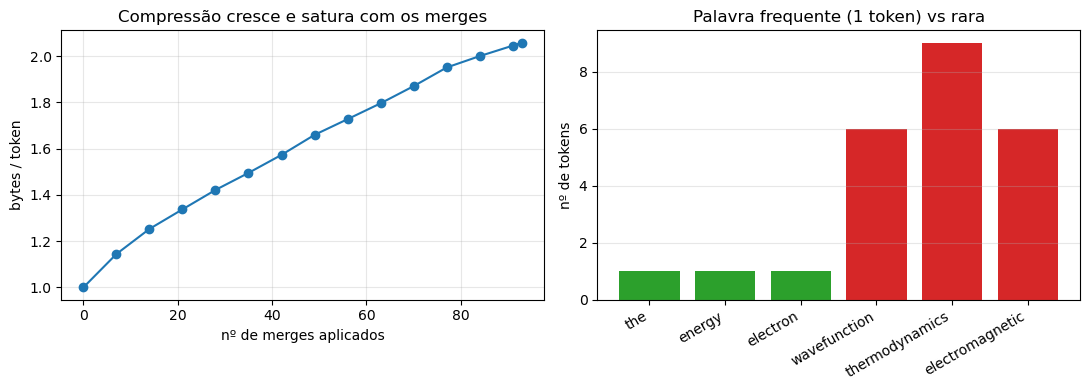

In [9]:
merge_items = list(merges.items())
# mede bytes/token aplicando os primeiros k merges, em ~12 pontos
step = max(1, len(merge_items) // 12)
ks = list(range(0, len(merge_items) + 1, step))
if ks[-1] != len(merge_items):
    ks.append(len(merge_items))
bpt = [n_bytes / len(encode(texto_medida, dict(merge_items[:k]))) for k in ks]

palavras = ["the", "energy", "electron", "wavefunction", "thermodynamics", "electromagnetic"]
n_tok = [len(encode(w, merges)) for w in palavras]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(ks, bpt, "o-", color="C0")
ax1.set_xlabel("nº de merges aplicados"); ax1.set_ylabel("bytes / token")
ax1.set_title("Compressão cresce e satura com os merges")

cores = ["C2" if n == 1 else "C3" for n in n_tok]
ax2.bar(range(len(palavras)), n_tok, color=cores)
ax2.set_xticks(range(len(palavras))); ax2.set_xticklabels(palavras, rotation=30, ha="right")
ax2.set_ylabel("nº de tokens"); ax2.set_title("Palavra frequente (1 token) vs rara")
ax2.grid(axis="x")
plt.tight_layout(); plt.show()

Note o padrão: palavras frequentes no corpus (`the`, `energy`) colapsam em poucos
tokens; palavras raras ou ausentes (`thermodynamics`) se quebram em mais pedaços.
É exatamente o comportamento desejado — o vocabulário se adapta à distribuição do
corpus.

## 6. Escolha de `vocab_size` (nb 02)

O GPT-2 original usa `V = 50257`. Aqui adotamos `V = 8192` (e `V = 4096` nos
experimentos). Por quê tão menor?

O custo escondido está na **embedding table**, de tamanho `V × d`. Para um corpus
pequeno, dois problemas:

1. Muitos tokens ficariam **raros** (mal treinados) num vocabulário gigante.
2. A embedding consome uma fatia **desproporcional** do orçamento de parâmetros.

Vamos fazer a conta para `d = 512` (preset *medium*):

In [10]:
d = 512
modelo_total = 43_000_000   # ~43M params do preset medium
for V in [8192, 50257]:
    emb_params = V * d
    pct = 100 * emb_params / modelo_total
    print(f"V={V:6d}: embedding = V*d = {emb_params:,} params "
          f"(~{pct:.0f}% de um modelo de 43M)")

print("\nCom V=50257 a embedding sozinha seria ~58% do modelo — desproporcional")
print("para corpus pequeno. V=8192 mantém isso em ~10%. (weight tying no nb 03")
print("ainda reaproveita essa matriz como projeção de saída, dobrando o ganho.)")

V=  8192: embedding = V*d = 4,194,304 params (~10% de um modelo de 43M)
V= 50257: embedding = V*d = 25,731,584 params (~60% de um modelo de 43M)

Com V=50257 a embedding sozinha seria ~58% do modelo — desproporcional
para corpus pequeno. V=8192 mantém isso em ~10%. (weight tying no nb 03
ainda reaproveita essa matriz como projeção de saída, dobrando o ganho.)


A figura deixa o trade-off óbvio: a fração do modelo gasta só na embedding cresce
linearmente com `vocab_size`. O `V=8192` do projeto (verde) fica numa faixa saudável;
o `V=50257` do GPT-2 (vermelho) domina o orçamento quando o modelo é pequeno.

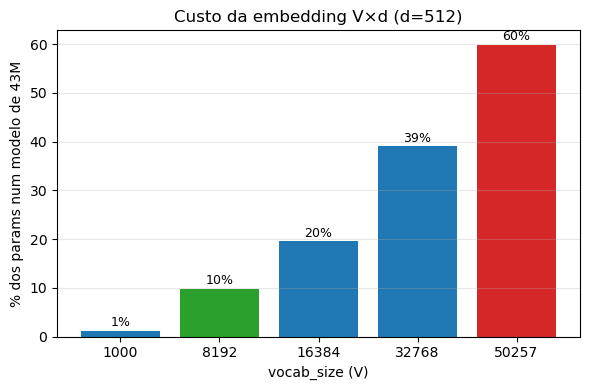

In [11]:
Vs = [1000, 8192, 16384, 32768, 50257]
pcts = [100 * V * d / modelo_total for V in Vs]

fig, ax = plt.subplots()
cores = ["C2" if V == 8192 else ("C3" if V == 50257 else "C0") for V in Vs]
ax.bar([str(V) for V in Vs], pcts, color=cores)
for i, p in enumerate(pcts):
    ax.text(i, p + 1, f"{p:.0f}%", ha="center", fontsize=9)
ax.set_xlabel("vocab_size (V)"); ax.set_ylabel("% dos params num modelo de 43M")
ax.set_title("Custo da embedding V×d (d=512)"); ax.grid(axis="x")
plt.tight_layout(); plt.show()

Trade-off resumido: `V` **maior** → sequências mais curtas (melhor compressão),
mas embedding mais cara e tokens mais raros. `V` **menor** → embedding barata e
tokens bem treinados, mas sequências mais longas. O ponto ótimo depende do tamanho
do corpus — para ~12,5M tokens, 8192 é um equilíbrio sensato.

## 7. Cache de tokens e a armadilha do `mtime` (nb 02)

Tokenizar 60 MB em Python leva ~145 s. Repetir isso a cada `train.py` é tempo
morto. A solução é **cachear os tokens em disco**: a primeira chamada codifica e
salva os IDs (ex.: `data/corpus_tokens.pt`); as seguintes carregam direto
(milissegundos).

A invalidação ingênua compara o `mtime` do corpus com o do cache: se o corpus é
mais novo, re-encoda. Isso pega mudanças no **corpus**, mas tem uma armadilha
séria:

> **Se você retreina o tokenizer mas o corpus não muda, o `mtime` do corpus não
> se altera — o cache fica obsoleto com IDs do tokenizer ANTIGO.** O treino roda
> com IDs que não correspondem mais à embedding, e falha silenciosamente.

Regra prática: **ao retreinar o tokenizer, delete o cache explicitamente.** Uma
versão mais robusta guardaria um *hash* do tokenizer no header do cache e
validaria na leitura. Vamos simular a armadilha para ela ficar concreta:

In [12]:
import os, tempfile, time

with tempfile.TemporaryDirectory() as tmp:
    corpus_f = os.path.join(tmp, "corpus.jsonl")
    cache_f  = os.path.join(tmp, "corpus_tokens.bin")

    with open(corpus_f, "w") as f:
        f.write("the electron has charge")

    def cache_valido(corpus_f, cache_f):
        # invalidação ingênua: só compara mtime (o que o projeto faz por padrão)
        if not os.path.exists(cache_f):
            return False
        return os.path.getmtime(cache_f) >= os.path.getmtime(corpus_f)

    # 1ª execução: cache não existe -> encoda e salva
    ids = encode(open(corpus_f).read(), merges)
    with open(cache_f, "wb") as f:
        f.write(bytes(i % 256 for i in ids))
    print("cache criado. válido agora?", cache_valido(corpus_f, cache_f))

    # Retreina o tokenizer (novos merges) SEM tocar no corpus:
    vocab2, merges2 = train_bpe(CORPUS, vocab_size=300)   # V diferente -> IDs diferentes
    print("tokenizer retreinado (IDs mudaram), mas corpus intacto.")
    print("mtime diz que o cache ainda é válido?", cache_valido(corpus_f, cache_f),
          "  <-- ARMADILHA: True, mas o cache está OBSOLETO")
    print("\nRegra: ao retreinar o tokenizer, apague o cache à mão.")

cache criado. válido agora? True
tokenizer retreinado (IDs mudaram), mas corpus intacto.
mtime diz que o cache ainda é válido? True   <-- ARMADILHA: True, mas o cache está OBSOLETO

Regra: ao retreinar o tokenizer, apague o cache à mão.


## Resumo (o que carregar para o notebook 03)

| Conceito | Decisão | Onde reaparece |
|---|---|---|
| Char-level | descartado: vocab com cauda longa + contexto curto | motivação do BPE |
| Byte-level (0–255) | cobertura total, sem `<UNK>` | base do vocab |
| Treino de merges (Alg. 1) | par mais frequente → token novo, repetir | `BPETokenizer.train` |
| Encoding (Alg. 2) | merges na ordem aprendida; decode sem perda | `.encode` / `.decode` |
| `vocab_size = 8192` | equilíbrio embedding `V×d` vs raridade | `ModelConfig.vocab_size` |
| Cache por `mtime` | rápido, mas apagar ao retreinar tokenizer | `load_or_cache_corpus` |

**Ponte para o código de produção:** o que você implementou aqui é exatamente o
esqueleto de `src/tucanoce/tokenizer/bpe.py` (`train`, `encode`, `decode`). A versão
de produção adiciona: tokens especiais no encoding, o salto para C via `ctypes` no
loop de encoding, e o cache com validação por hash.

**Caminho de evolução:** leia o *minbpe* (Karpathy) para uma implementação limpa e
os `tokenizers` da HuggingFace (backend Rust) para ver o algoritmo com estruturas
incrementais — ordens de magnitude mais rápido que este loop didático.

Próximo: **`03_arquitetura_base.ipynb`** — o transformer decoder-only que consome
esses IDs.